PROCESO OPTIMIZADO CON SVR - REDUCCIÓN DIMENSIONAL
RFE vs PERMUTATION IMPORTANCE vs POLYNOMIAL KERNEL

Cargando datos de entrenamiento desde: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\3_meteo_epi_2021-2026_1_rezagos_meteo_train_80_20.xlsx
Datos de entrenamiento: 216 muestras, 157 características
Iniciando ingeniería de atributos optimizada...
Escalando características...
Características después de ingeniería: 177

EVALUANDO MÉTODOS DE REDUCCIÓN: RFE vs PERMUTATION vs POLY KERNEL

Calculando importancia por permutación...

Probando 10 características...
  Evaluando RFE...
    MAE: 10.8214, R²: 0.4209, Peak MAE: 43.7268
  Evaluando Permutation Importance...
    MAE: 11.1669, R²: 0.4711, Peak MAE: 39.1346
  Evaluando Polynomial Kernel + SVD...
    MAE: 14.2747, R²: 0.2580, Peak MAE: 46.3899

Probando 15 características...
  Evaluando RFE...
    MAE: 11.2909, R²: 0.4303, Peak MAE: 42.0729
  Evaluando Permutation Importance...
    MAE: 11.2

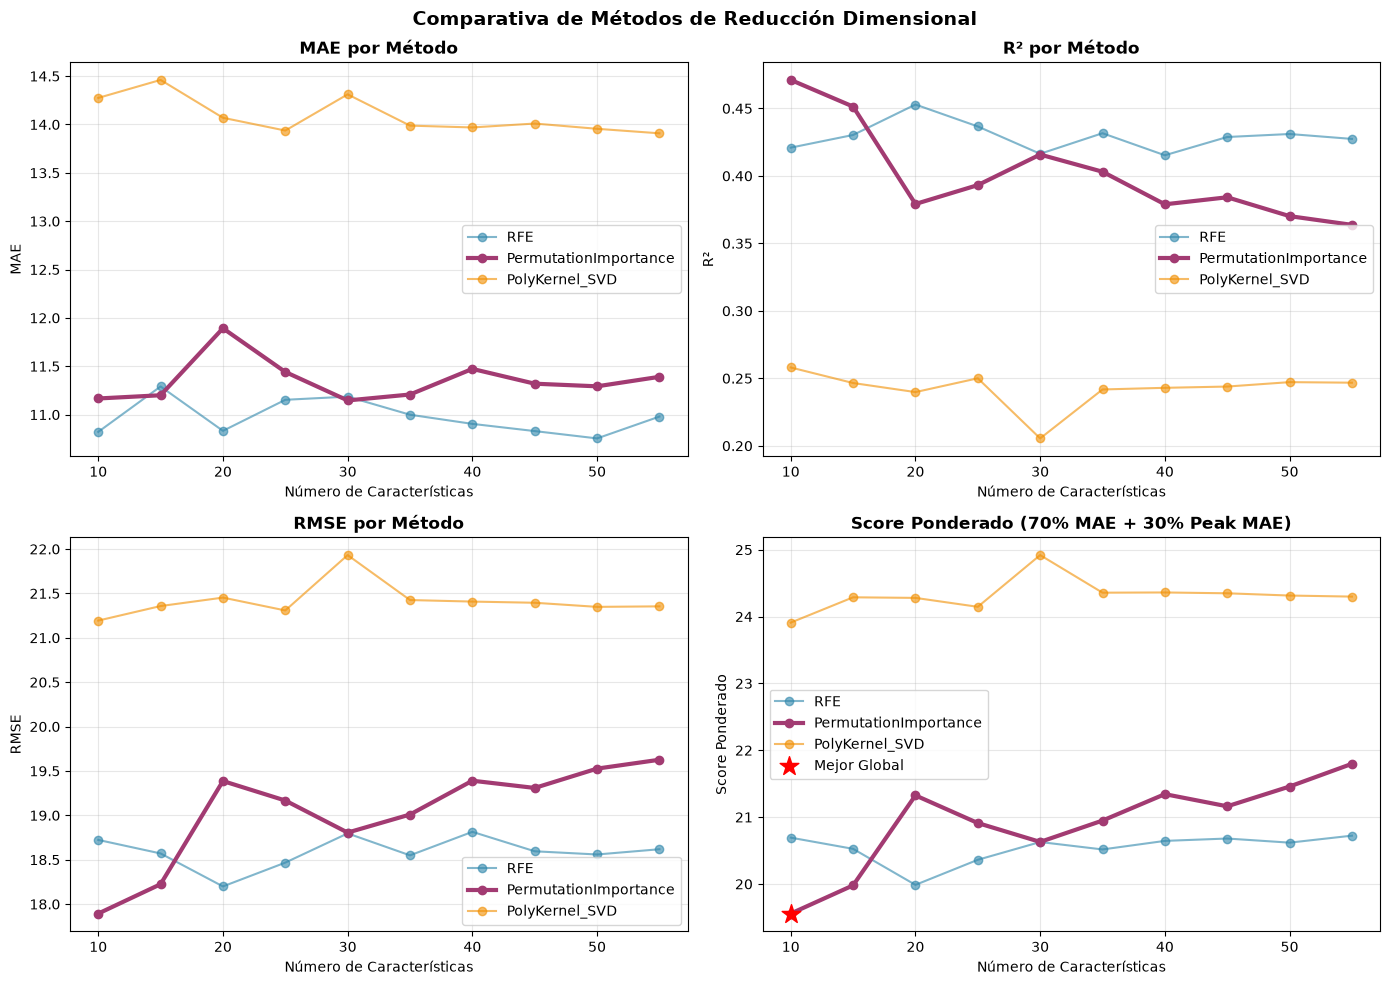

✅ Análisis de picos guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\peak_analysis_svr.png


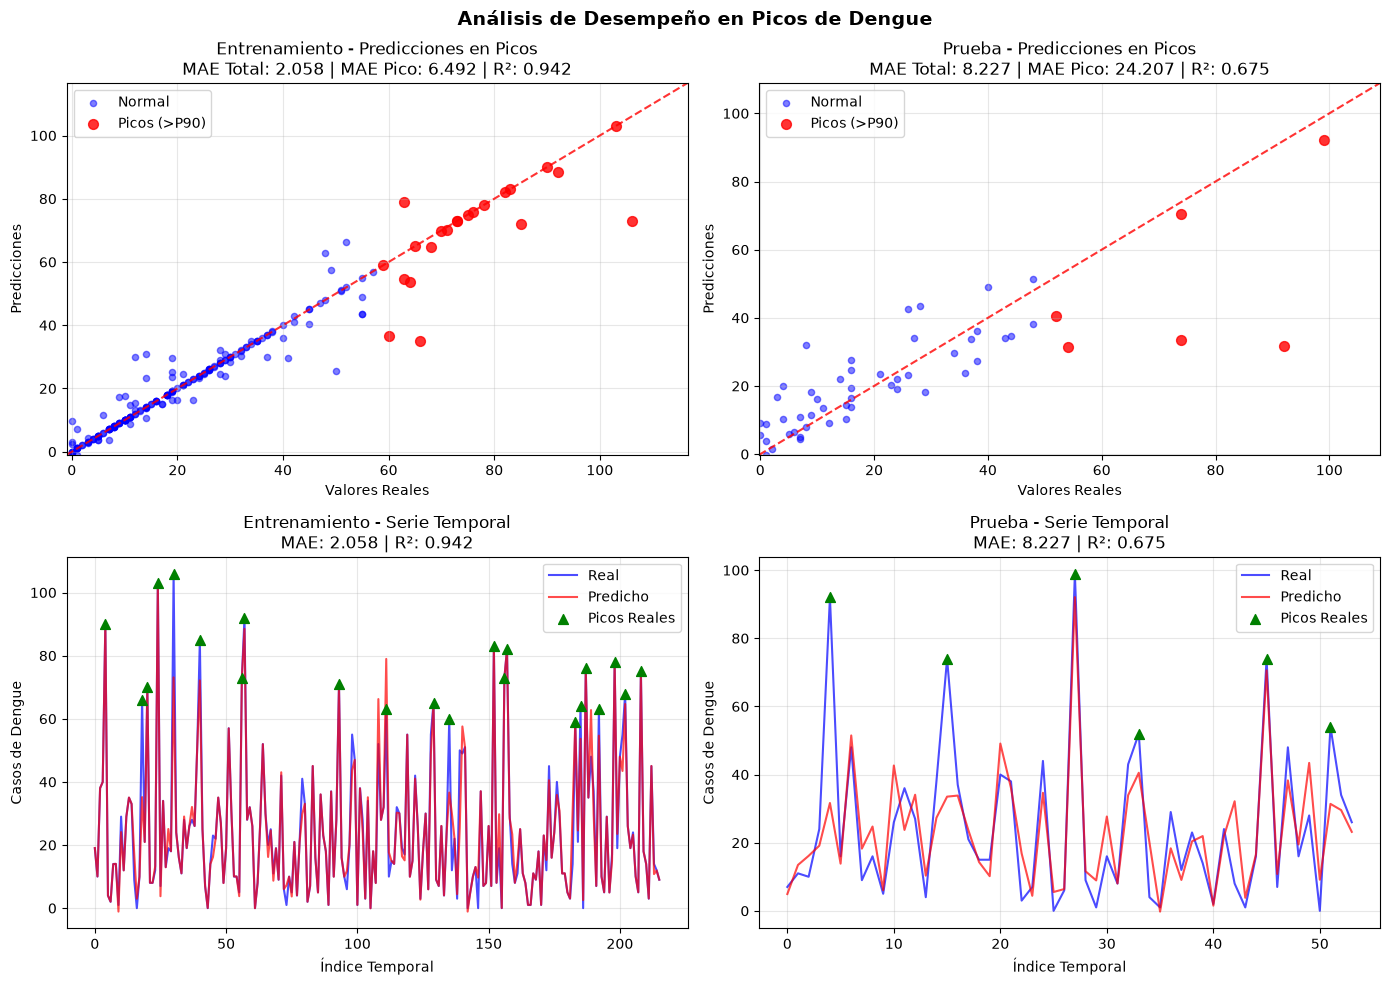

✅ Comparación guardada en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\performance_comparison_svr.png


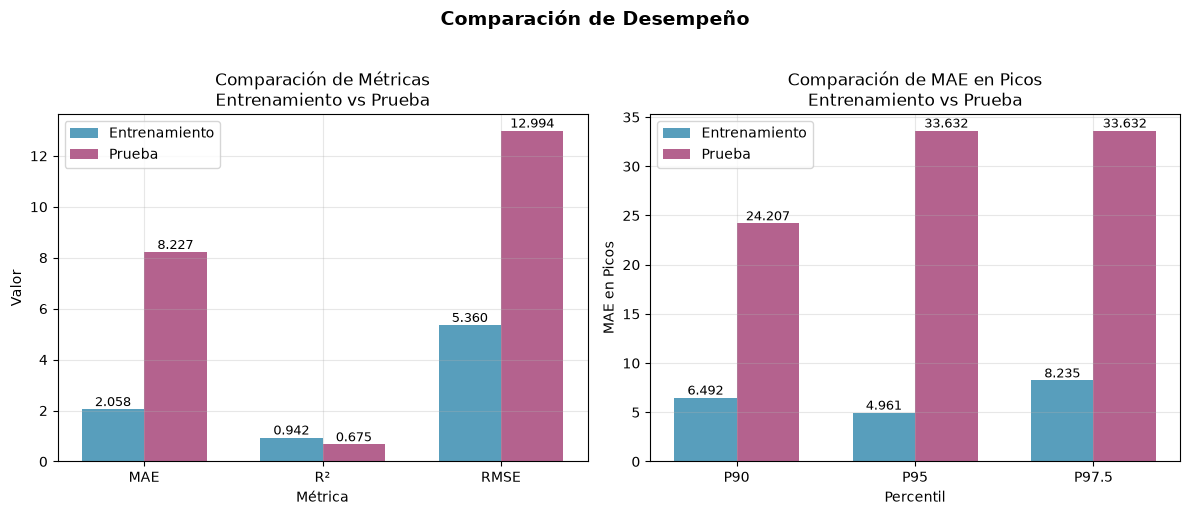

 Script de despliegue SVR generado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\modelo_svr_despliegue.py

PROCESO SVR COMPLETADO EXITOSAMENTE
Resultados: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\resultados_svr_reduccion_dimensional.xlsx
Gráfico comparativo: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\reduccion_dimensional_comparativa.png
Análisis de picos: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\peak_analysis_svr.png
Comparación desempeño: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\performance_comparison_svr.png
Modelo guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\modelo_svr_guardado


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.decomposition import TruncatedSVD
from sklearn.kernel_approximation import PolynomialCountSketch
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import warnings
import os
from datetime import datetime
import json
import pickle

warnings.filterwarnings('ignore')

class DengueFeatureEngineeringOptimized:
    def __init__(self, n_features_to_select=25):
        """
        Clase optimizada para ingeniería de atributos y reducción dimensional
        evaluando RFE, Permutation Importance y Kernels Polinómicos.
        """
        self.n_features_to_select = n_features_to_select
        self.scaler = StandardScaler()
        self.selected_features = None
        self.feature_names = None
        self.svr_model = None
        self.numeric_columns = None
        self.best_params = None
        self.X_augmented_columns = None
        self.best_metrics = None
        self.best_method = None
        self.poly_kernel_transformer = None
        self.svd_transformer = None
        self.feature_selection_results = None
        
    def create_interaction_features(self, X):
        """Crea características de interacción para variables meteorológicas"""
        interaction_data = pd.DataFrame(index=X.index)
        
        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
        ]
        
        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]
        
        return interaction_data
    
    def create_polynomial_features(self, X):
        """Crea características polinomiales para variables climáticas clave"""
        important_vars = ['temp', 'hum_rel', 'prec']
        poly_features = pd.DataFrame(index=X.index)
        
        for var in important_vars:
            if var in X.columns:
                poly_features[f'{var}_squared'] = X[var] ** 2
        
        return poly_features
    
    def create_lag_aggregates(self, X):
        """Crea agregados de rezagos para variables meteorológicas"""
        lag_aggs = pd.DataFrame(index=X.index)
        
        for base_var in ['temp', 'temp_max', 'temp_min', 'hum_rel', 'prec', 'dias_lluvia']:
            lag_cols = [col for col in X.columns if col.startswith(f'{base_var}_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[f'{base_var}_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[f'{base_var}_lag_std'] = lag_data.std(axis=1)
        
        return lag_aggs
    
    def create_rolling_features(self, X):
        """Crea características de tendencia temporal"""
        rolling_features = pd.DataFrame(index=X.index)
        
        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)
        
        return rolling_features
    
    def get_numeric_columns(self, X):
        """Identifica columnas numéricas (excluyendo fecha)"""
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []
        
        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)
        
        return numeric_cols
    
    def augment_features(self, X):
        """Aplica ingeniería de atributos a cualquier conjunto de datos"""
        numeric_cols = self.get_numeric_columns(X)
        X_numeric = X[numeric_cols]
        
        features_list = [X_numeric]
        
        interaction_features = self.create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)
        
        poly_features = self.create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)
        
        lag_aggs = self.create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)
        
        rolling_features = self.create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)
        
        X_augmented = pd.concat(features_list, axis=1)
        
        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())
        
        return X_augmented, X_numeric
    
    def fit_transform(self, X, y=None):
        """Aplica transformaciones con regularización"""
        print("Iniciando ingeniería de atributos optimizada...")
        
        X_augmented, X_numeric = self.augment_features(X)
        
        self.numeric_columns = X_numeric.columns.tolist()
        self.X_augmented_columns = X_augmented.columns.tolist()
        self.feature_names = X_augmented.columns.tolist()
        
        print("Escalando características...")
        X_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        print(f"Características después de ingeniería: {X_augmented.shape[1]}")
        
        return X_scaled, X_augmented
    
    def transform_features(self, X):
        """Aplica transformación a nuevos datos"""
        X_augmented, X_numeric = self.augment_features(X)
        
        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0
        
        X_augmented = X_augmented[self.X_augmented_columns]
        
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        return X_scaled
    
    def _evaluate_feature_subset(self, X_tr, y_tr, X_v, y_v):
        """Evalúa un subconjunto transformado mediante un SVR base"""
        base_svr = SVR(
            kernel='rbf',
            C=10,
            gamma='scale',
            epsilon=0.1,
            cache_size=500
        )
        base_svr.fit(X_tr, y_tr)
        y_pred = base_svr.predict(X_v)
        
        mae = mean_absolute_error(y_v, y_pred)
        r2 = r2_score(y_v, y_pred)
        rmse = np.sqrt(mean_squared_error(y_v, y_pred))
        
        peak_threshold = np.percentile(y_v, 90)
        peak_mask = y_v > peak_threshold
        peak_mae = mean_absolute_error(y_v[peak_mask], y_pred[peak_mask]) if np.sum(peak_mask) > 0 else float('inf')
        
        return mae, r2, rmse, peak_mae, peak_threshold, np.sum(peak_mask)

    def find_optimal_features(self, X_scaled, y, feature_range=None):
        """
        Encuentra la mejor técnica de reducción y el número óptimo de características
        comparando: RFE, Permutation Importance y Kernel Polinómico (Explicit Approximations).
        """
        if feature_range is None:
            feature_range = range(10, min(80, X_scaled.shape[1]), 5)

        print("\n" + "="*60)
        print("EVALUANDO MÉTODOS DE REDUCCIÓN: RFE vs PERMUTATION vs POLY KERNEL")
        print("="*60)

        X_train_val, X_val, y_train_val, y_val = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

        results = []
        best_overall_score = float('inf')
        best_config = {}

        # 1. Precalculo de Importancia por Permutación sobre el modelo base
        print("\nCalculando importancia por permutación...")
        rf_perm = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
        rf_perm.fit(X_train_val, y_train_val)
        perm_imp = permutation_importance(rf_perm, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1)
        sorted_perm_indices = np.argsort(perm_imp.importances_mean)[::-1]

        for n_features in feature_range:
            print(f"\nProbando {n_features} características...")

            # --- Método 1: RFE ---
            print(f"  Evaluando RFE...")
            rf_rfe = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
            rfe = RFE(estimator=rf_rfe, n_features_to_select=n_features, step=3)
            X_tr_rfe = rfe.fit_transform(X_train_val, y_train_val)
            X_v_rfe = rfe.transform(X_val)
            mae_r, r2_r, rmse_r, p_mae_r, p_th, n_p = self._evaluate_feature_subset(X_tr_rfe, y_train_val, X_v_rfe, y_val)
            w_score_r = 0.7 * mae_r + 0.3 * p_mae_r
            results.append({
                'method': 'RFE', 'n_features': n_features, 'mae': mae_r, 'r2': r2_r, 
                'rmse': rmse_r, 'peak_mae': p_mae_r, 'weighted_score': w_score_r
            })
            print(f"    MAE: {mae_r:.4f}, R²: {r2_r:.4f}, Peak MAE: {p_mae_r:.4f}")

            # --- Método 2: Permutation Importance ---
            print(f"  Evaluando Permutation Importance...")
            top_perm_cols = X_scaled.columns[sorted_perm_indices[:n_features]].tolist()
            X_tr_perm = X_train_val[top_perm_cols]
            X_v_perm = X_val[top_perm_cols]
            mae_p, r2_p, rmse_p, p_mae_p, _, _ = self._evaluate_feature_subset(X_tr_perm, y_train_val, X_v_perm, y_val)
            w_score_p = 0.7 * mae_p + 0.3 * p_mae_p
            results.append({
                'method': 'PermutationImportance', 'n_features': n_features, 'mae': mae_p, 'r2': r2_p, 
                'rmse': rmse_p, 'peak_mae': p_mae_p, 'weighted_score': w_score_p
            })
            print(f"    MAE: {mae_p:.4f}, R²: {r2_p:.4f}, Peak MAE: {p_mae_p:.4f}")

            # --- Método 3: Polynomial Kernel Expansion + SVD ---
            print(f"  Evaluando Polynomial Kernel + SVD...")
            poly_sketch = PolynomialCountSketch(degree=2, n_components=min(200, X_scaled.shape[1]*2), random_state=42)
            svd = TruncatedSVD(n_components=n_features, random_state=42)
            
            X_tr_poly = svd.fit_transform(poly_sketch.fit_transform(X_train_val))
            X_v_poly = svd.transform(poly_sketch.transform(X_val))
            mae_k, r2_k, rmse_k, p_mae_k, _, _ = self._evaluate_feature_subset(X_tr_poly, y_train_val, X_v_poly, y_val)
            w_score_k = 0.7 * mae_k + 0.3 * p_mae_k
            results.append({
                'method': 'PolyKernel_SVD', 'n_features': n_features, 'mae': mae_k, 'r2': r2_k, 
                'rmse': rmse_k, 'peak_mae': p_mae_k, 'weighted_score': w_score_k
            })
            print(f"    MAE: {mae_k:.4f}, R²: {r2_k:.4f}, Peak MAE: {p_mae_k:.4f}")

            # Selección del mejor candidato global
            for m_name, w_sc, mae, r2, rmse, p_mae in [
                ('RFE', w_score_r, mae_r, r2_r, rmse_r, p_mae_r),
                ('PermutationImportance', w_score_p, mae_p, r2_p, rmse_p, p_mae_p),
                ('PolyKernel_SVD', w_score_k, mae_k, r2_k, rmse_k, p_mae_k)
            ]:
                if w_sc < best_overall_score:
                    best_overall_score = w_sc
                    best_config = {
                        'method': m_name, 'n_features': n_features,
                        'metrics': {'mae': mae, 'r2': r2, 'rmse': rmse, 'peak_mae': p_mae},
                        'rfe_obj': rfe if m_name == 'RFE' else None,
                        'perm_cols': top_perm_cols if m_name == 'PermutationImportance' else None,
                        'poly_obj': poly_sketch if m_name == 'PolyKernel_SVD' else None,
                        'svd_obj': svd if m_name == 'PolyKernel_SVD' else None
                    }

        print("\n" + "="*60)
        print(f"✅ MEJOR MÉTODO DETECTADO: {best_config['method']}")
        print(f"   Número óptimo de características: {best_config['n_features']}")
        print(f"   MAE: {best_config['metrics']['mae']:.4f}")
        print(f"   R²: {best_config['metrics']['r2']:.4f}")
        print(f"   RMSE: {best_config['metrics']['rmse']:.4f}")
        print(f"   MAE en picos: {best_config['metrics']['peak_mae']:.4f}")
        print("="*60)

        self.best_method = best_config['method']
        self.n_features_to_select = best_config['n_features']
        self.best_metrics = best_config['metrics']
        self.feature_selection_results = pd.DataFrame(results)

        if self.best_method == 'RFE':
            self.selected_features = X_scaled.columns[best_config['rfe_obj'].support_].tolist()
        elif self.best_method == 'PermutationImportance':
            self.selected_features = best_config['perm_cols']
        else:
            self.poly_kernel_transformer = best_config['poly_obj']
            self.svd_transformer = best_config['svd_obj']
            self.selected_features = [f'PolyKernel_Comp_{i+1}' for i in range(self.n_features_to_select)]

        return self.n_features_to_select, results, best_config['metrics']
    
    def transform_with_selected_features(self, X_scaled):
        """Transforma usando las características seleccionadas según el mejor método"""
        if self.best_method in ['RFE', 'PermutationImportance']:
            return X_scaled[self.selected_features]
        elif self.best_method == 'PolyKernel_SVD':
            X_poly = self.poly_kernel_transformer.transform(X_scaled)
            X_svd = self.svd_transformer.transform(X_poly)
            return pd.DataFrame(X_svd, columns=self.selected_features, index=X_scaled.index)
    
    def tune_hyperparameters(self, X_train, y_train, X_test, y_test):
        """
        Realiza búsqueda de hiperparámetros para SVR
        """
        print("\n" + "="*60)
        print("AJUSTE DE HIPERPARÁMETROS DEL MODELO SVR")
        print("="*60)
        
        # Definir grid de hiperparámetros optimizado
        param_grid = {
            'kernel': ['rbf', 'poly'],
            'C': [1, 5, 10, 20, 50, 100],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.05, 0.1, 0.5, 1],
            'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
            'degree': [2, 3]  # Solo para kernel poly
        }
        
        print("Realizando búsqueda de hiperparámetros con RandomizedSearchCV...")
        
        svr = SVR(cache_size=500)
        
        random_search = RandomizedSearchCV(
            estimator=svr,
            param_distributions=param_grid,
            n_iter=80,
            cv=3,
            scoring='neg_mean_absolute_error',
            n_jobs=-1,
            random_state=42,
            verbose=1
        )
        
        random_search.fit(X_train, y_train)
        
        best_params = random_search.best_params_
        best_model = random_search.best_estimator_
        
        print("\n" + "="*60)
        print("✅ MEJORES HIPERPARÁMETROS ENCONTRADOS:")
        print("="*60)
        for key, value in best_params.items():
            print(f"  {key}: {value}")
        
        # Evaluar en test
        y_pred_test = best_model.predict(X_test)
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)
        
        # Evaluar en train
        y_pred_train = best_model.predict(X_train)
        mae_train = mean_absolute_error(y_train, y_pred_train)
        r2_train = r2_score(y_train, y_pred_train)
        
        print(f"\nMAE Train: {mae_train:.4f}")
        print(f"MAE Test: {mae_test:.4f}")
        print(f"R² Train: {r2_train:.4f}")
        print(f"R² Test: {r2_test:.4f}")
        
        # Guardar resultados
        self.best_params = best_params
        self.svr_model = best_model
        self.train_val_metrics = {
            'mae_train': mae_train,
            'r2_train': r2_train,
            'mae_test': mae_test,
            'r2_test': r2_test,
            'overfit_gap': mae_test - mae_train
        }
        
        return best_params, best_model
    
    def evaluate_model_detailed(self, X_test, y_test, dataset_name="Test"):
        """Evalúa el modelo con métricas detalladas incluyendo picos"""
        y_pred = self.svr_model.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        peak_metrics = {}
        for p in [90, 95, 97.5]:
            threshold = np.percentile(y_test, p)
            peak_mask = y_test > threshold
            if np.sum(peak_mask) > 0:
                peak_mae = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])
                peak_r2 = r2_score(y_test[peak_mask], y_pred[peak_mask]) if len(y_test[peak_mask]) > 1 else np.nan
                peak_metrics[f'P{p}_MAE'] = peak_mae
                peak_metrics[f'P{p}_R2'] = peak_r2
                peak_metrics[f'P{p}_Threshold'] = threshold
                peak_metrics[f'P{p}_Count'] = np.sum(peak_mask)
        
        print(f"\n{'='*60}")
        print(f"MÉTRICAS DETALLADAS - {dataset_name}")
        print(f"{'='*60}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"\nMétricas para picos:")
        for key, value in peak_metrics.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")
        
        return {
            'MAE': mae,
            'R2': r2,
            'RMSE': rmse,
            'peak_metrics': peak_metrics,
            'predictions': y_pred,
            'actual': y_test.values if hasattr(y_test, 'values') else y_test
        }


# ==========================================
# FUNCIONES DE GRAFICACIÓN
# ==========================================

def plot_feature_selection_results(results, best_metrics, save_path=None):
    """Grafica los resultados de la comparación de métodos de reducción"""
    df = pd.DataFrame(results)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    methods = df['method'].unique()
    colors = {'RFE': '#2E86AB', 'PermutationImportance': '#A23B72', 'PolyKernel_SVD': '#F18F01'}
    
    ax1, ax2, ax3, ax4 = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]
    
    # Encontrar el método ganador
    best_method = df.loc[df['weighted_score'].idxmin(), 'method']
    
    for m in methods:
        sub = df[df['method'] == m]
        linewidth = 3 if m == best_method else 1.5
        alpha = 1.0 if m == best_method else 0.6
        
        ax1.plot(sub['n_features'], sub['mae'], marker='o', 
                label=f'{m}', color=colors[m], linewidth=linewidth, alpha=alpha)
        ax2.plot(sub['n_features'], sub['r2'], marker='o', 
                label=f'{m}', color=colors[m], linewidth=linewidth, alpha=alpha)
        ax3.plot(sub['n_features'], sub['rmse'], marker='o', 
                label=f'{m}', color=colors[m], linewidth=linewidth, alpha=alpha)
        ax4.plot(sub['n_features'], sub['weighted_score'], marker='o', 
                label=f'{m}', color=colors[m], linewidth=linewidth, alpha=alpha)
    
    # Marcar el mejor punto en cada gráfico
    best_idx = df['weighted_score'].idxmin()
    ax4.scatter(df.loc[best_idx, 'n_features'], df.loc[best_idx, 'weighted_score'], 
               color='red', s=200, marker='*', zorder=5, label='Mejor Global')

    ax1.set_title("MAE por Método", fontsize=12, fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax1.set_xlabel("Número de Características")
    ax1.set_ylabel("MAE")
    
    ax2.set_title("R² por Método", fontsize=12, fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    ax2.set_xlabel("Número de Características")
    ax2.set_ylabel("R²")
    
    ax3.set_title("RMSE por Método", fontsize=12, fontweight='bold')
    ax3.legend(); ax3.grid(True, alpha=0.3)
    ax3.set_xlabel("Número de Características")
    ax3.set_ylabel("RMSE")
    
    ax4.set_title("Score Ponderado (70% MAE + 30% Peak MAE)", fontsize=12, fontweight='bold')
    ax4.legend(); ax4.grid(True, alpha=0.3)
    ax4.set_xlabel("Número de Características")
    ax4.set_ylabel("Score Ponderado")

    plt.suptitle('Comparativa de Métodos de Reducción Dimensional', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de selección guardado en: {save_path}")
    plt.show()
    return fig


def plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=None):
    """Analiza y grafica el desempeño en picos"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Comparación de predicciones en picos - Train
    ax1 = axes[0, 0]
    train_actual = train_metrics['actual']
    train_pred = train_metrics['predictions']
    threshold_train = np.percentile(train_actual, 90)
    peak_mask_train = train_actual > threshold_train
    
    ax1.scatter(train_actual[~peak_mask_train], train_pred[~peak_mask_train], 
                alpha=0.5, color='blue', label='Normal', s=20)
    ax1.scatter(train_actual[peak_mask_train], train_pred[peak_mask_train], 
                alpha=0.8, color='red', label='Picos (>P90)', s=50)
    
    min_val = min(train_actual.min(), train_pred.min()) * 0.9
    max_val = max(train_actual.max(), train_pred.max()) * 1.1
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax1.set_xlabel('Valores Reales')
    ax1.set_ylabel('Predicciones')
    peak_mae_train = train_metrics['peak_metrics'].get('P90_MAE', 0)
    ax1.set_title(f'Entrenamiento - Predicciones en Picos\nMAE Total: {train_metrics["MAE"]:.3f} | MAE Pico: {peak_mae_train:.3f} | R²: {train_metrics["R2"]:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    
    # 2. Comparación de predicciones en picos - Test
    ax2 = axes[0, 1]
    test_actual = test_metrics['actual']
    test_pred = test_metrics['predictions']
    threshold_test = np.percentile(test_actual, 90)
    peak_mask_test = test_actual > threshold_test
    
    ax2.scatter(test_actual[~peak_mask_test], test_pred[~peak_mask_test], 
                alpha=0.5, color='blue', label='Normal', s=20)
    ax2.scatter(test_actual[peak_mask_test], test_pred[peak_mask_test], 
                alpha=0.8, color='red', label='Picos (>P90)', s=50)
    
    min_val = min(test_actual.min(), test_pred.min()) * 0.9
    max_val = max(test_actual.max(), test_pred.max()) * 1.1
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax2.set_xlabel('Valores Reales')
    ax2.set_ylabel('Predicciones')
    peak_mae_test = test_metrics['peak_metrics'].get('P90_MAE', 0)
    ax2.set_title(f'Prueba - Predicciones en Picos\nMAE Total: {test_metrics["MAE"]:.3f} | MAE Pico: {peak_mae_test:.3f} | R²: {test_metrics["R2"]:.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)
    
    # 3. Serie temporal - Train
    ax3 = axes[1, 0]
    indices_train = np.arange(len(train_actual))
    ax3.plot(indices_train, train_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax3.plot(indices_train, train_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_train = np.where(peak_mask_train)[0]
    ax3.scatter(peak_indices_train, train_actual[peak_mask_train], 
               color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax3.set_xlabel('Índice Temporal')
    ax3.set_ylabel('Casos de Dengue')
    ax3.set_title(f'Entrenamiento - Serie Temporal\nMAE: {train_metrics["MAE"]:.3f} | R²: {train_metrics["R2"]:.3f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Serie temporal - Test
    ax4 = axes[1, 1]
    indices_test = np.arange(len(test_actual))
    ax4.plot(indices_test, test_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax4.plot(indices_test, test_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_test = np.where(peak_mask_test)[0]
    ax4.scatter(peak_indices_test, test_actual[peak_mask_test], 
               color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax4.set_xlabel('Índice Temporal')
    ax4.set_ylabel('Casos de Dengue')
    ax4.set_title(f'Prueba - Serie Temporal\nMAE: {test_metrics["MAE"]:.3f} | R²: {test_metrics["R2"]:.3f}')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('Análisis de Desempeño en Picos de Dengue', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Análisis de picos guardado en: {save_path}")
    
    plt.show()
    return fig


def plot_performance_comparison(train_metrics, test_metrics, save_path=None):
    """Grafica comparación de desempeño entre entrenamiento y prueba"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Comparación de métricas
    ax1 = axes[0]
    metrics = ['MAE', 'R²', 'RMSE']
    train_values = [train_metrics['MAE'], train_metrics['R2'], train_metrics['RMSE']]
    test_values = [test_metrics['MAE'], test_metrics['R2'], test_metrics['RMSE']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, train_values, width, label='Entrenamiento', color='#2E86AB', alpha=0.8)
    bars2 = ax1.bar(x + width/2, test_values, width, label='Prueba', color='#A23B72', alpha=0.8)
    
    ax1.set_xlabel('Métrica')
    ax1.set_ylabel('Valor')
    ax1.set_title('Comparación de Métricas\nEntrenamiento vs Prueba')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # 2. Comparación de MAE en picos
    ax2 = axes[1]
    peak_percentiles = [90, 95, 97.5]
    train_peak_mae = [train_metrics['peak_metrics'].get(f'P{p}_MAE', 0) for p in peak_percentiles]
    test_peak_mae = [test_metrics['peak_metrics'].get(f'P{p}_MAE', 0) for p in peak_percentiles]
    
    x = np.arange(len(peak_percentiles))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, train_peak_mae, width, label='Entrenamiento', color='#2E86AB', alpha=0.8)
    bars2 = ax2.bar(x + width/2, test_peak_mae, width, label='Prueba', color='#A23B72', alpha=0.8)
    
    ax2.set_xlabel('Percentil')
    ax2.set_ylabel('MAE en Picos')
    ax2.set_title('Comparación de MAE en Picos\nEntrenamiento vs Prueba')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'P{p}' for p in peak_percentiles])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    for bar in bars1:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('Comparación de Desempeño', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Comparación guardada en: {save_path}")
    
    plt.show()
    return fig


def save_detailed_results(results, feature_results, best_metrics, selected_features, 
                          feature_importance, best_params, train_val_metrics, filepath):
    """Guarda resultados detallados en Excel incluyendo características seleccionadas"""
    try:
        with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
            # Métricas generales
            df_metrics = pd.DataFrame({
                'Dataset': ['Train', 'Test'],
                'MAE': [results['train']['MAE'], results['test']['MAE']],
                'R2': [results['train']['R2'], results['test']['R2']],
                'RMSE': [results['train']['RMSE'], results['test']['RMSE']]
            })
            df_metrics.to_excel(writer, sheet_name='Métricas', index=False)
            
            # Métricas de picos
            peak_data = []
            for dataset in ['train', 'test']:
                for p in [90, 95, 97.5]:
                    key = f'P{p}_MAE'
                    if key in results[dataset]['peak_metrics']:
                        peak_data.append({
                            'Dataset': dataset.capitalize(),
                            'Percentil': p,
                            'MAE_Pico': results[dataset]['peak_metrics'][f'P{p}_MAE'],
                            'R2_Pico': results[dataset]['peak_metrics'][f'P{p}_R2'],
                            'Threshold': results[dataset]['peak_metrics'][f'P{p}_Threshold'],
                            'N_Picos': results[dataset]['peak_metrics'][f'P{p}_Count']
                        })
            
            if peak_data:
                df_peak = pd.DataFrame(peak_data)
                df_peak.to_excel(writer, sheet_name='Métricas_Picos', index=False)
            
            # Características seleccionadas
            df_selected_features = pd.DataFrame({
                'Feature': selected_features
            })
            df_selected_features.to_excel(writer, sheet_name='Características_Seleccionadas', index=False)
            
            # Métricas del mejor modelo
            df_best_metrics = pd.DataFrame({
                'Métrica': ['MAE', 'R²', 'RMSE', 'MAE_Picos(P90)'],
                'Valor': [best_metrics['mae'], best_metrics['r2'], best_metrics['rmse'], best_metrics['peak_mae']]
            })
            df_best_metrics.to_excel(writer, sheet_name='Mejor_Modelo_Métricas', index=False)
            
            # Mejores hiperparámetros
            if best_params:
                df_params = pd.DataFrame({
                    'Parámetro': list(best_params.keys()),
                    'Valor': list(best_params.values())
                })
                df_params.to_excel(writer, sheet_name='Mejores_Hiperparámetros', index=False)
            
            # Métricas de validación
            if train_val_metrics:
                df_tuning = pd.DataFrame({
                    'Métrica': ['MAE Train', 'MAE Test', 'R² Train', 'R² Test', 'Brecha Sobreajuste'],
                    'Valor': [
                        train_val_metrics['mae_train'],
                        train_val_metrics['mae_test'],
                        train_val_metrics['r2_train'],
                        train_val_metrics['r2_test'],
                        train_val_metrics['overfit_gap']
                    ]
                })
                df_tuning.to_excel(writer, sheet_name='Validación_Hiperparámetros', index=False)
            
            # Resultados de selección de características
            if feature_results:
                df_feature_search = pd.DataFrame(feature_results)
                df_feature_search.to_excel(writer, sheet_name='Búsqueda_Features', index=False)
            
            # Predicciones
            max_len = max(len(results['train']['actual']), len(results['test']['actual']))
            
            train_actual = np.pad(results['train']['actual'], (0, max_len - len(results['train']['actual'])), 
                                 constant_values=np.nan)
            train_pred = np.pad(results['train']['predictions'], (0, max_len - len(results['train']['predictions'])), 
                               constant_values=np.nan)
            test_actual = np.pad(results['test']['actual'], (0, max_len - len(results['test']['actual'])), 
                                constant_values=np.nan)
            test_pred = np.pad(results['test']['predictions'], (0, max_len - len(results['test']['predictions'])), 
                              constant_values=np.nan)
            
            df_predictions = pd.DataFrame({
                'Train_Actual': train_actual,
                'Train_Predicted': train_pred,
                'Test_Actual': test_actual,
                'Test_Predicted': test_pred
            })
            df_predictions.to_excel(writer, sheet_name='Predicciones', index=False)
        
        print(f"✅ Resultados detallados guardados en: {filepath}")
    except Exception as e:
        print(f"⚠️ Error al guardar en Excel: {e}")


def generate_deployment_script(engine, output_dir, base_path):
    """Genera un script Python para implementar el modelo entrenado"""
    
    script_content = '''"""
Script de despliegue del modelo SVR para predicción de casos de dengue
Generado automáticamente - {fecha}

Este script permite cargar el modelo entrenado y realizar predicciones
sobre nuevos datos con el mismo formato que los datos de entrenamiento.
"""

import pandas as pd
import numpy as np
import pickle
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

class DengueModelDeployment:
    """
    Clase para desplegar el modelo SVR de predicción de casos de dengue
    """
    def __init__(self, model_dir):
        self.model_dir = model_dir
        self.load_model()
    
    def load_model(self):
        """Carga el modelo y los objetos necesarios desde archivos"""
        with open(os.path.join(self.model_dir, 'scaler.pkl'), 'rb') as f:
            self.scaler = pickle.load(f)
        
        with open(os.path.join(self.model_dir, 'svr_model.pkl'), 'rb') as f:
            self.svr_model = pickle.load(f)
        
        with open(os.path.join(self.model_dir, 'model_config.json'), 'r') as f:
            config = json.load(f)
            self.selected_features = config['selected_features']
            self.X_augmented_columns = config['X_augmented_columns']
            self.best_method = config.get('best_method', 'RFE')
            self.best_params = config.get('best_params', {})
            self.poly_kernel_transformer = None
            self.svd_transformer = None
            
            if self.best_method == 'PolyKernel_SVD':
                with open(os.path.join(self.model_dir, 'poly_kernel.pkl'), 'rb') as f:
                    self.poly_kernel_transformer = pickle.load(f)
                with open(os.path.join(self.model_dir, 'svd_transformer.pkl'), 'rb') as f:
                    self.svd_transformer = pickle.load(f)
        
        print(f" Modelo SVR cargado exitosamente (Método: {self.best_method})")
        print(f"   Características seleccionadas: {len(self.selected_features)}")
    
    def _create_interaction_features(self, X):
        interaction_data = pd.DataFrame(index=X.index)
        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
        ]
        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]
        return interaction_data
    
    def _create_polynomial_features(self, X):
        important_vars = ['temp', 'hum_rel', 'prec']
        poly_features = pd.DataFrame(index=X.index)
        for var in important_vars:
            if var in X.columns:
                poly_features[var + '_squared'] = X[var] ** 2
        return poly_features
    
    def _create_lag_aggregates(self, X):
        lag_aggs = pd.DataFrame(index=X.index)
        for base_var in ['temp', 'temp_max', 'temp_min', 'hum_rel', 'prec', 'dias_lluvia']:
            lag_cols = [col for col in X.columns if col.startswith(base_var + '_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[base_var + '_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[base_var + '_lag_std'] = lag_data.std(axis=1)
        return lag_aggs
    
    def _create_rolling_features(self, X):
        rolling_features = pd.DataFrame(index=X.index)
        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)
        return rolling_features
    
    def _get_numeric_columns(self, X):
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []
        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)
        return numeric_cols
    
    def _augment_features(self, X):
        numeric_cols = self._get_numeric_columns(X)
        X_numeric = X[numeric_cols]
        features_list = [X_numeric]
        
        interaction_features = self._create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)
        
        poly_features = self._create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)
        
        lag_aggs = self._create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)
        
        rolling_features = self._create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)
        
        X_augmented = pd.concat(features_list, axis=1)
        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())
        return X_augmented
    
    def predict(self, X):
        X_augmented = self._augment_features(X)
        
        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0
        
        X_augmented = X_augmented[self.X_augmented_columns]
        
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        if self.best_method == 'PolyKernel_SVD':
            X_poly = self.poly_kernel_transformer.transform(X_scaled)
            X_final = self.svd_transformer.transform(X_poly)
        else:
            X_final = X_scaled[self.selected_features]
        
        predictions = self.svr_model.predict(X_final)
        return predictions
    
    def predict_and_save(self, X, output_path=None):
        predictions = self.predict(X)
        results_df = X.copy()
        results_df['prediccion_casos_dengue'] = predictions
        if output_path:
            results_df.to_excel(output_path, index=False)
            print(f" Predicciones guardadas en: {output_path}")
        return results_df

if __name__ == "__main__":
    print("="*60)
    print("SCRIPT DE DESPLIEGUE DEL MODELO SVR PARA DENGUE")
    print("="*60)
    
    model_dir = r"{model_dir}"
    model = DengueModelDeployment(model_dir)
    
    print("\\nCargando datos de prueba...")
    test_path = r"{test_path}"
    test_data = pd.read_excel(test_path)
    X_test = test_data.drop('casos_dengue', axis=1)
    
    print("Realizando predicciones...")
    predictions = model.predict(X_test)
    
    print(f"Predicciones generadas para {len(predictions)} muestras")
    print(f"Estadísticas de predicciones:")
    print(f"  Media: {np.mean(predictions):.2f}")
    print(f"  Mediana: {np.median(predictions):.2f}")
    print(f"  Mínimo: {np.min(predictions):.2f}")
    print(f"  Máximo: {np.max(predictions):.2f}")
    
    output_path = os.path.join(model_dir, "predicciones_ejemplo.xlsx")
    model.predict_and_save(X_test, output_path)
'''
    
    script_content = script_content.replace('{fecha}', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    script_path = os.path.join(output_dir, "modelo_svr_despliegue.py")
    
    model_dir_abs = os.path.join(output_dir, "modelo_svr_guardado")
    test_path_abs = os.path.join(base_path, "3_meteo_epi_2021-2026_1_rezagos_meteo_test_80_20.xlsx")
    
    script_content = script_content.replace('{model_dir}', model_dir_abs)
    script_content = script_content.replace('{test_path}', test_path_abs)
    
    with open(script_path, 'w', encoding='utf-8') as f:
        f.write(script_content)
    
    print(f" Script de despliegue SVR generado en: {script_path}")
    return script_path


# ===================== EJECUCIÓN PRINCIPAL =====================

if __name__ == "__main__":
    print("="*60)
    print("PROCESO OPTIMIZADO CON SVR - REDUCCIÓN DIMENSIONAL")
    print("RFE vs PERMUTATION IMPORTANCE vs POLYNOMIAL KERNEL")
    print("="*60)
    
    # Configurar rutas
    base_path = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20"
    output_dir = base_path
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Cargar datos de entrenamiento
    train_path = os.path.join(base_path, "3_meteo_epi_2021-2026_1_rezagos_meteo_train_80_20.xlsx")
    print(f"\nCargando datos de entrenamiento desde: {train_path}")
    train_data = pd.read_excel(train_path)
    
    X_train = train_data.drop('casos_dengue', axis=1)
    y_train = train_data['casos_dengue']
    
    print(f"Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características")
    
    # Inicializar y aplicar ingeniería de atributos
    engine = DengueFeatureEngineeringOptimized()
    X_scaled, X_augmented = engine.fit_transform(X_train, y_train)
    
    # Encontrar el mejor método de reducción dimensional
    feature_range = range(10, min(60, X_scaled.shape[1]), 5)
    best_n_features, feature_results, best_metrics = engine.find_optimal_features(
        X_scaled, y_train, feature_range
    )
    
    # Dividir datos para tuning
    X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(
        X_scaled, y_train, test_size=0.2, random_state=42
    )
    
    # Seleccionar características óptimas
    X_train_selected = engine.transform_with_selected_features(X_train_tune)
    X_test_selected = engine.transform_with_selected_features(X_test_tune)
    
    # Ajustar hiperparámetros
    best_params, model = engine.tune_hyperparameters(
        X_train_selected, y_train_tune, X_test_selected, y_test_tune
    )
    
    # Evaluar en entrenamiento completo
    print("\n" + "="*60)
    print("EVALUANDO MODELO SVR OPTIMIZADO EN DATOS DE ENTRENAMIENTO")
    print("="*60)
    X_train_full_selected = engine.transform_with_selected_features(X_scaled)
    train_metrics = engine.evaluate_model_detailed(X_train_full_selected, y_train, "Train")
    
    # Cargar datos de prueba
    test_path = os.path.join(base_path, "3_meteo_epi_2021-2026_1_rezagos_meteo_test_80_20.xlsx")
    print(f"\nCargando datos de prueba desde: {test_path}")
    test_data = pd.read_excel(test_path)
    
    X_test = test_data.drop('casos_dengue', axis=1)
    y_test = test_data['casos_dengue']
    
    print(f"Datos de prueba: {X_test.shape[0]} muestras, {X_test.shape[1]} características")
    
    # Aplicar transformación a datos de prueba
    X_test_scaled = engine.transform_features(X_test)
    X_test_selected_final = engine.transform_with_selected_features(X_test_scaled)
    
    # Evaluar en prueba
    print("\n" + "="*60)
    print("EVALUANDO MODELO SVR OPTIMIZADO EN DATOS DE PRUEBA")
    print("="*60)
    test_metrics = engine.evaluate_model_detailed(X_test_selected_final, y_test, "Test")
    
    # Resumen final
    print("\n" + "="*60)
    print("RESUMEN FINAL DE DESEMPEÑO")
    print("="*60)
    print(f"Mejor método de reducción: {engine.best_method}")
    print(f"Características seleccionadas: {len(engine.selected_features)}")
    print(f"\nTrain - MAE: {train_metrics['MAE']:.4f}, R²: {train_metrics['R2']:.4f}")
    print(f"Test  - MAE: {test_metrics['MAE']:.4f}, R²: {test_metrics['R2']:.4f}")
    print(f"\nMAE en picos (>P90):")
    print(f"  Train: {train_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    print(f"  Test:  {test_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    
    overfit_gap_final = test_metrics['MAE'] - train_metrics['MAE']
    print(f"\nBrecha de sobreajuste final: {overfit_gap_final:.4f}")
    
    print(f"\nMejores hiperparámetros:")
    for key, value in best_params.items():
        print(f"  {key}: {value}")
    
    # Verificar objetivos
    print("\n" + "-"*60)
    if train_metrics['MAE'] < 3 and test_metrics['MAE'] < 3:
        print("¡OBJETIVO CUMPLIDO! MAE < 3 en entrenamiento y prueba")
    else:
        print(f"MAE > 3. Train: {train_metrics['MAE']:.4f}, Test: {test_metrics['MAE']:.4f}")
    
    if train_metrics['R2'] > 0.9 and test_metrics['R2'] > 0.85:
        print("¡OBJETIVO CUMPLIDO! R² > 0.9 en entrenamiento y > 0.85 en prueba")
    else:
        print(f"R² podría mejorar. Train: {train_metrics['R2']:.4f}, Test: {test_metrics['R2']:.4f}")
    
    # Guardar resultados
    results = {'train': train_metrics, 'test': test_metrics}
    
    excel_output = os.path.join(output_dir, "resultados_svr_reduccion_dimensional.xlsx")
    save_detailed_results(
        results, feature_results, best_metrics,
        engine.selected_features, [],
        best_params, engine.train_val_metrics, excel_output
    )
    
    # Gráficos
    feature_plot = os.path.join(output_dir, "reduccion_dimensional_comparativa.png")
    plot_feature_selection_results(feature_results, best_metrics, save_path=feature_plot)
    
    peak_plot = os.path.join(output_dir, "peak_analysis_svr.png")
    plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=peak_plot)
    
    comparison_plot = os.path.join(output_dir, "performance_comparison_svr.png")
    plot_performance_comparison(train_metrics, test_metrics, save_path=comparison_plot)
    
    # Guardar modelo
    model_dir = os.path.join(output_dir, "modelo_svr_guardado")
    os.makedirs(model_dir, exist_ok=True)
    
    with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(engine.scaler, f)
    
    with open(os.path.join(model_dir, 'svr_model.pkl'), 'wb') as f:
        pickle.dump(engine.svr_model, f)
    
    if engine.best_method == 'PolyKernel_SVD':
        with open(os.path.join(model_dir, 'poly_kernel.pkl'), 'wb') as f:
            pickle.dump(engine.poly_kernel_transformer, f)
        with open(os.path.join(model_dir, 'svd_transformer.pkl'), 'wb') as f:
            pickle.dump(engine.svd_transformer, f)
    
    config = {
        'selected_features': engine.selected_features,
        'X_augmented_columns': engine.X_augmented_columns,
        'best_method': engine.best_method,
        'best_params': best_params,
        'best_metrics': best_metrics,
        'train_mae': train_metrics['MAE'],
        'test_mae': test_metrics['MAE'],
        'train_r2': train_metrics['R2'],
        'test_r2': test_metrics['R2'],
        'overfit_gap': overfit_gap_final
    }
    
    with open(os.path.join(model_dir, 'model_config.json'), 'w') as f:
        json.dump(config, f, indent=4)
    
    generate_deployment_script(engine, output_dir, base_path)
    
    print("\n" + "="*60)
    print("PROCESO SVR COMPLETADO EXITOSAMENTE")
    print("="*60)
    print(f"Resultados: {excel_output}")
    print(f"Gráfico comparativo: {feature_plot}")
    print(f"Análisis de picos: {peak_plot}")
    print(f"Comparación desempeño: {comparison_plot}")
    print(f"Modelo guardado en: {model_dir}")